# Hot jupiter migration project

In this notebook, we wish to study the formation of hot Jupiters by Kozai-Lidov (KL) oscillations and tidal dissipation using REBOUND and REBOUNDx.   

The goal is to recreate Figure 1 from [Anderson K. R. et al (2016)](https://doi.org/10.1093/mnras/stv2906), where the orbit of a Jupiter circularizes and goes sub 0.5 AU, making it a Hot Jupiter.   

We begin by initializing the system. Here there are different options of forces to add such as tidal dissipation, GR, both or none. The semimajor axis of the secondary star can also be chosen. We choose 50 AU to reduce the Kozai time, however the reference paper chooses 200 AU in their first figure.   

Initial conditions:
- Planet; a0=1.5 AU, e0=0.01, theta_lb0=85, Mp=5Mjup
- Binary: eb=0, ab=50AU, m*=1 solar mass (for eachh star)

*units are in AU and MSun
Hierarchical triple system; inner binary and outer binary  

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import rebound
import reboundx
import time
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import logging
logging.getLogger('matplotlib').setLevel(logging.ERROR) #surpresses an annoying warning message
plt.close()

#params
mjup= 9.547e-4 #in solar masses 
rjup = 0.00047  #in AU
rsun = 0.00465 

def sim_setup(integrator = "ias15", dt = 0.1, a_star=200, forces =None):
    # set up the simulation
    sim = rebound.Simulation()
    sim.integrator = integrator
    if integrator == "WHFAST":
        sim.dt = dt
    elif integrator == "mercurius":
        sim.ri_mercurius.r_crit_hill = 4.
    else:
        sim.ri_ias15.epsilon = 1e-7
    sim.units = ('yr', 'AU', 'Msun')
    sim.add(m=1) #central star
    sim.add(m=1e-3, a=1.5, e=0.01, inc=np.deg2rad(85)) #jupiter 
    sim.add(m=1, a=a_star, e=0, inc=np.deg2rad(0)) #outer star
    sim.move_to_com()

    star   = sim.particles[0]
    planet = sim.particles[1]
    star.r   = rsun
    planet.r = rjup

    #forces (or no forces)
    if forces == None:
        pass
    elif forces == 'tidal':
        rebx = reboundx.Extras(sim)
        tides = rebx.load_force("tides_constant_time_lag")
        rebx.add_force(tides)
        planet.params["tctl_k2"]  = 0.37 #love num
        planet.params["tctl_tau"] = 1 / (365.25 * 24 * 3600) 
    elif forces == 'gr':
        rebx = reboundx.Extras(sim)
        gr = rebx.load_force("gr")
        rebx.add_force(gr)
        gr.params["c"] = 63241.0
    elif forces == 'all':
        rebx = reboundx.Extras(sim)
        tides = rebx.load_force("tides_constant_time_lag")
        rebx.add_force(tides)
        planet.params["tctl_k2"]  = 0.37 #love num
        planet.params["tctl_tau"] = 1 / (365.25 * 24 * 3600) 
        gr = rebx.load_force("gr")
        rebx.add_force(gr)
        gr.params["c"] = 63241.0
    
    #printing a few params
    P_inner = sim.particles[1].P  
    P_outer = sim.particles[2].P  
    t_kozai = (1 / 1) * (P_outer**2) / P_inner  #/10**6 # Rough estimate in years, try moving star in
    hill = 1.5 * (5*mjup/(3*1))**(1/3)
    print(f"Approximate Kozai timescale: {t_kozai:.4f} yr")
    print('Inner period: ',P_inner, "Outer period",P_outer)
    print("Hill Radius:", hill)

    return sim, t_kozai

# example of a set up with no forces
# sim = sim_setup(a_star=50)
# op = rebound.OrbitPlotSet(sim, periastron=False, color =True, unitlabel="[AU]")


In [2]:
#evolution 
def evolve(sim, Noutputs=500, t_end=6e7, op =None):

    times = np.linspace(0, t_end, Noutputs) 
    #planet
    xvec = np.zeros(Noutputs)
    yvec = np.zeros(Noutputs)
    zvec = np.zeros(Noutputs)
    ep = np.zeros(Noutputs)
    inc   = np.zeros(Noutputs)
    ap   = np.zeros(Noutputs)
    xvec[0] = sim.particles[1].x
    yvec[0] = sim.particles[1].y
    zvec[0] = sim.particles[1].z

    #star 1
    x1 = np.zeros(Noutputs)
    y1 = np.zeros(Noutputs)
    z1 = np.zeros(Noutputs)
    x1[0] = sim.particles[0].x
    y1[0] = sim.particles[0].y
    z1[0] = sim.particles[0].z

    #star 2
    x2 = np.zeros(Noutputs)
    y2 = np.zeros(Noutputs)
    z2 = np.zeros(Noutputs)
    x2[0] = sim.particles[2].x
    y2[0] = sim.particles[2].y
    z2[0] = sim.particles[2].z

    if op != None: 
        op = rebound.OrbitPlotSet(sim, periastron=False, color =True, unitlabel="[AU]")
        op2, = plt.plot(xvec[:1], yvec[:1])
        opstar2, = plt.plot(x2[:1], y2[:1])
    elif op == None:
        pass

    for i, t in enumerate(times):

        if op != None:
            op.sim.integrate(t) #removed op.
        elif op == None:
            sim.integrate(t)

        #store the trajectory of planet (index 1)
        xvec[i] = sim.particles[1].x
        yvec[i] = sim.particles[1].y
        zvec[i] = sim.particles[1].z
        ap[i] = sim.orbits()[0].a
        ep[i] = sim.orbits()[0].e
        inc[i] = sim.orbits()[0].inc

        # star1
        x1[i] = sim.particles[0].x
        y1[i] = sim.particles[0].y
        z1[i] = sim.particles[0].z

        # star2
        x2[i] = sim.particles[2].x
        y2[i] = sim.particles[2].y
        z2[i] = sim.particles[2].z

        #np.save('/mnt/c/Users/Amili/Documents/phys633_rebound/progress.npy', np.array([times, ap, ep, inc]))
        #np.save('/mnt/c/Users/Amili/Documents/phys633_rebound/progress_pos.npy', np.array([xvec,yvec,zvec,x1,y1,z1,x2,y2,z2]))

        # #update the plot to animate it
        if op != None:
            op.update() # can use updateLimits=True if you want to dynamically update the plot limits
            op2.set_data((xvec[:i+1],yvec[:i+1])) # plot the trajectory so far
            opstar2.set_data((x2[:i+1],y2[:i+1]))
            time.sleep(0.001)
            op.fig.canvas.draw()
        elif op == None:
            pass
    return ap,ep,inc,times
#ap,ep,inc,times = evolve(sim, Noutputs=500, t_end=6e7, op =None)

## Plotting code

The following functions can be used to plot the inner orbit of the Jupiter in different planes and the semimajor axis, eccentricity and inclination angle, which recreates Figure 1 from the paper. Note that I save my figures in my local directory as widget has been causing problems with my plt.show().

In [3]:
def plot_orbits(xvec, yvec,zvec,x1,y1,z1):
    plt.close()
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # --- panel 2: planet relative to host star ---
    x_rel = xvec - x1
    y_rel = yvec - y1
    z_rel = zvec - z1
    colors = np.linspace(0, 1, len(x_rel))

    axes[0].scatter(x_rel, y_rel, c=colors, cmap='magma', label='Planet')
    axes[0].plot(0, 0, 'k*', ms=12, label='Host star')
    axes[0].set_xlabel('x (AU)')
    axes[0].set_ylabel('y (AU)')
    axes[0].set_title('Planet orbit (relative to host star)')

    axes[1].scatter(y_rel, z_rel, c=colors, cmap='magma', label='Planet')
    axes[1].plot(0, 0, 'k*', ms=12, label='Host star')
    axes[1].set_xlabel('y (AU)')
    axes[1].set_ylabel('z (AU)')
    axes[1].set_title('Planet orbit (relative to host star)')
    axes[1].legend()

    axes[2].scatter(x_rel, z_rel, c=colors, cmap='magma', label='Planet')
    axes[2].plot(0, 0, 'k*', ms=12, label='Host star')
    axes[2].set_xlabel('y (AU)')
    axes[2].set_ylabel('x (AU)')
    axes[2].set_title('Planet orbit (relative to host star)')
    plt.show()
#plot_orbits(xvec, yvec,zvec,x1,y1,z1)

In [4]:
def plot_e_and_i(ap, ep, inc, times, savename='test.png'):
    plt.close('all')
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].plot(times/1e9, ap)
    axes[0].set_xlabel('time [Gyr]')
    axes[0].set_ylabel('a')
    axes[0].set_title('Planet semimajor axis')
    axes[0].set_xscale('log')
    #axes[0].text(x=10e-5, y=0.2, s=f"Max e at t = {t_max/1e6:.3f} Myr")
    #axes[0].axvline(x=t_max/1e9, color='gray', alpha=0.5, linestyle='--')
    
    axes[1].plot(times/1e9, 1-ep)
    axes[1].axhline(y=1, color='gray', alpha=0.5, linestyle='--')
    axes[1].set_xlabel('time [Gyr]')
    axes[1].set_ylabel('1-e')
    axes[1].set_title('Planet eccentricity')
    axes[1].set_xscale('log')
    
    axes[2].plot(times/1e9, np.degrees(inc))
    axes[2].set_xlabel('time [Gyr]')
    axes[2].set_ylabel(r'$\theta_{lb}$')
    axes[2].set_title('inclination angle')
    axes[2].set_xscale('log')
    
    #plt.tight_layout()
    plt.savefig(savename, dpi=200)
    plt.show()
    plt.close(fig)
    print(f"saved to {savename}")

## Running the code

In this section we run the code using different forces and compare the results with one another
First we run a test with Kozai oscillations only, which should take on the order of a minute.

In [5]:
# No forces, LK only
sim1, tk1 = sim_setup(a_star=50)
ap1,ep1,inc1,times1 = evolve(sim1, Noutputs=500, t_end=30*tk1, op =None)

Approximate Kozai timescale: 34021.3292 yr
Inner period:  1.8362341163217868 Outer period 249.94224389481124
Hill Radius: 0.17511760801914616


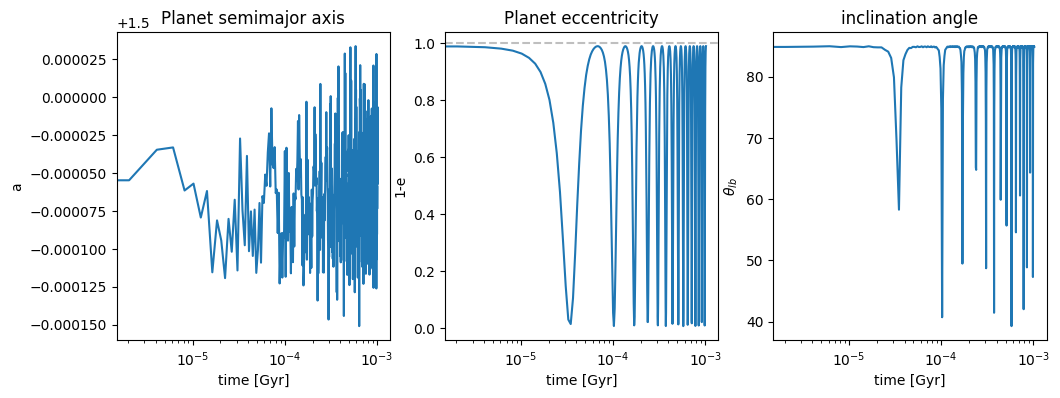

saved to Kozai.png


In [6]:
plot_e_and_i(ap1, ep1, inc1, times1, savename = "Kozai.png")

We now run with forces. For reference, the tidal only force took around 186 minutes to run to attain circularization for ~100 t_kozai (3.361 Myr).

In [7]:
#tidal forces
sim2, tk2 = sim_setup(a_star=50, forces ='tidal')
ap2,ep2,inc2,times2 = evolve(sim2, Noutputs=500, t_end=30*tk2, op =None)

Approximate Kozai timescale: 34021.3292 yr
Inner period:  1.8362341163217868 Outer period 249.94224389481124
Hill Radius: 0.17511760801914616


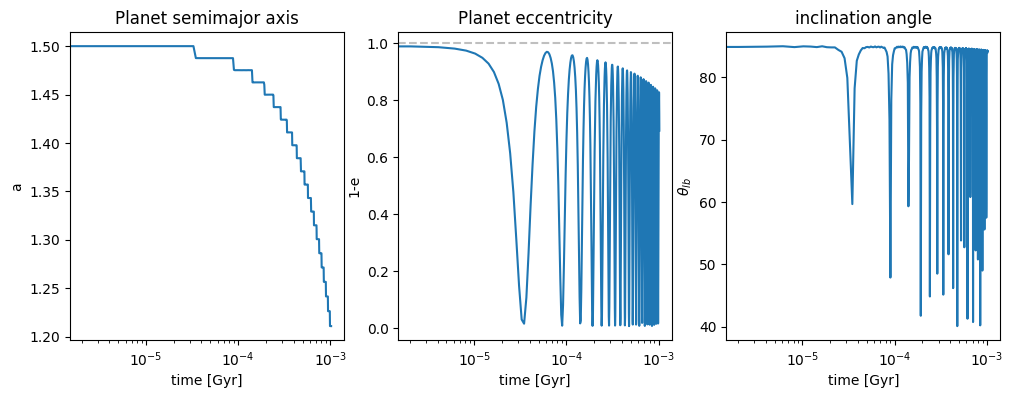

saved to Kozai_tides.png


In [8]:
plot_e_and_i(ap2, ep2, inc2, times2, savename = "Kozai_tides.png")

In [9]:
#GR 
sim3, tk3 = sim_setup(a_star=50, forces ='gr')
ap3,ep3,inc3,times3 = evolve(sim3, Noutputs=500, t_end=30*tk3, op =None)

Approximate Kozai timescale: 34021.3292 yr
Inner period:  1.8362341163217868 Outer period 249.94224389481124
Hill Radius: 0.17511760801914616


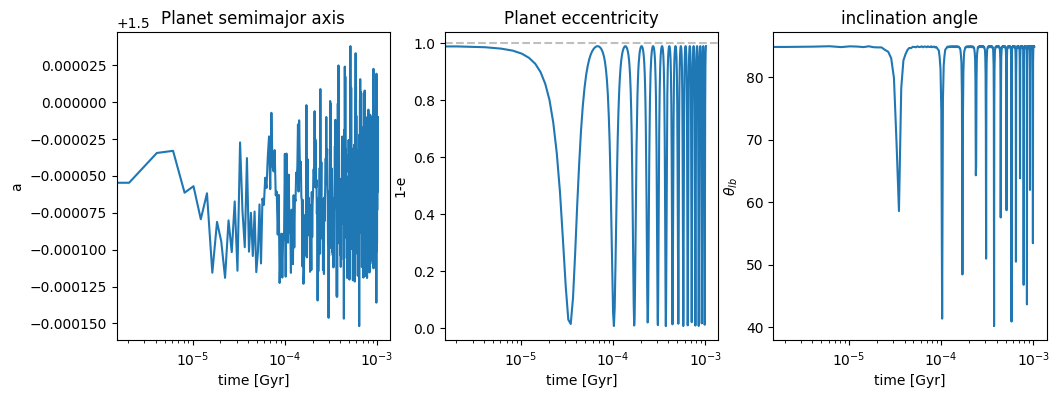

saved to Kozai_gr.png


In [10]:
plot_e_and_i(ap3, ep3, inc3, times3, savename = "Kozai_gr.png")

In [11]:
#all effects 
sim4, tk4 = sim_setup(a_star=50, forces ='all')
ap4,ep4,inc4,times4 = evolve(sim4, Noutputs=500, t_end=30*tk4, op =None)

Approximate Kozai timescale: 34021.3292 yr
Inner period:  1.8362341163217868 Outer period 249.94224389481124
Hill Radius: 0.17511760801914616


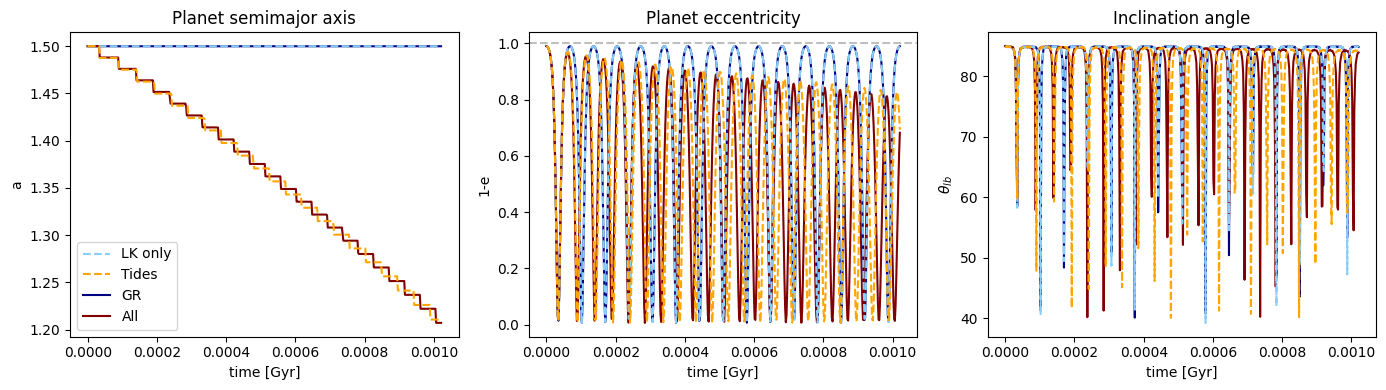

<Figure size 640x480 with 0 Axes>

In [12]:
#plotting effects over each other 
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(times1/1e9, ap1, color ='lightskyblue', linestyle='--',label='LK only')
axes[0].plot(times2/1e9, ap2, color ='orange', linestyle='--', label='Tides')
axes[0].plot(times3/1e9, ap3, color ='navy', label='GR', zorder=0)
axes[0].plot(times4/1e9, ap4, color ='maroon', label='All', zorder=1)
axes[0].set_xlabel('time [Gyr]')
axes[0].set_ylabel('a')
axes[0].set_title('Planet semimajor axis')
#axes[0].set_xscale('log')
axes[0].legend()
#axes[0].text(x=10e-5, y=0.2, s=f"Max e at t = {t_max/1e6:.3f} Myr")
#axes[0].axvline(x=t_max/1e9, color='gray', alpha=0.5, linestyle='--')

axes[1].plot(times1/1e9, 1-ep1,color ='lightskyblue', linestyle='--')
axes[1].plot(times2/1e9, 1-ep2,color ='orange', linestyle='--')
axes[1].plot(times3/1e9, 1-ep3,color ='navy', zorder=0)
axes[1].plot(times4/1e9, 1-ep4,color ='maroon', zorder=1)
axes[1].axhline(y=1, color='gray', alpha=0.5, linestyle='--')
axes[1].set_xlabel('time [Gyr]')
axes[1].set_ylabel('1-e')
axes[1].set_title('Planet eccentricity')
#axes[1].set_xscale('log')

axes[2].plot(times1/1e9, np.degrees(inc1), color ='lightskyblue',linestyle='--')
axes[2].plot(times2/1e9, np.degrees(inc2), color ='orange',linestyle='--')
axes[2].plot(times3/1e9, np.degrees(inc3), color ='navy', zorder=0)
axes[2].plot(times4/1e9, np.degrees(inc4), color ='maroon', zorder=1)
axes[2].set_xlabel('time [Gyr]')
axes[2].set_ylabel(r'$\theta_{lb}$')
axes[2].set_title('Inclination angle')
#axes[2].set_xscale('log')

plt.tight_layout()
plt.show()
plt.savefig("combined_effects.png", dpi=200)
plt.close(fig)


In [13]:
#200 AU and 50 AU comparison 
#all effects 
sim5, tk5 = sim_setup(a_star=200, forces ='all')
ap5,ep5,inc5,times5 = evolve(sim5, Noutputs=500, t_end=2*tk5, op =None)

Approximate Kozai timescale: 2177365.0661 yr
Inner period:  1.8362341163217868 Outer period 1999.53795115849
Hill Radius: 0.17511760801914616


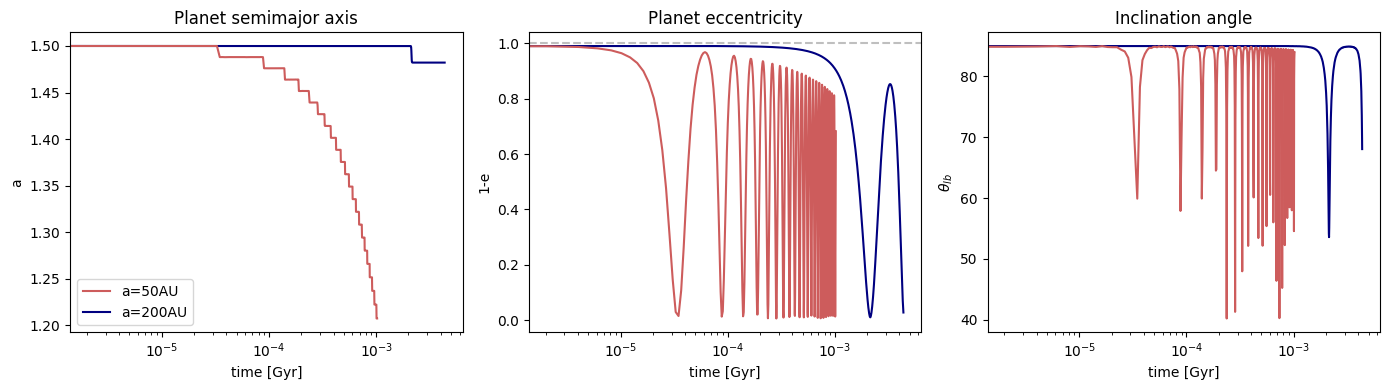

<Figure size 640x480 with 0 Axes>

In [14]:
#plotting effects over each other 
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(times4/1e9, ap4, color ='indianred', label='a=50AU', zorder=1)
axes[0].plot(times5/1e9, ap5, color ='navy', label='a=200AU', zorder=0)
axes[0].set_xlabel('time [Gyr]')
axes[0].set_ylabel('a')
axes[0].set_title('Planet semimajor axis')
axes[0].set_xscale('log')
axes[0].legend()
#axes[0].text(x=10e-5, y=0.2, s=f"Max e at t = {t_max/1e6:.3f} Myr")
#axes[0].axvline(x=t_max/1e9, color='gray', alpha=0.5, linestyle='--')

axes[1].plot(times4/1e9, 1-ep4,color ='indianred', zorder=1)
axes[1].plot(times5/1e9, 1-ep5,color ='navy', zorder=0)
axes[1].axhline(y=1, color='gray', alpha=0.5, linestyle='--')
axes[1].set_xlabel('time [Gyr]')
axes[1].set_ylabel('1-e')
axes[1].set_title('Planet eccentricity')
axes[1].set_xscale('log')

axes[2].plot(times4/1e9, np.degrees(inc4), color ='indianred', zorder=1)
axes[2].plot(times5/1e9, np.degrees(inc5), color ='navy', zorder=0)
axes[2].set_xlabel('time [Gyr]')
axes[2].set_ylabel(r'$\theta_{lb}$')
axes[2].set_title('Inclination angle')
axes[2].set_xscale('log')

plt.tight_layout()
plt.show()
plt.savefig("comparison.png", dpi=200)
plt.close(fig)
